In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.patches as mpatches
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import plotly.express as px
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib
import seaborn as sns
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")

pandas: 2.2.2
scikit-learn: 1.6.1
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2


In [7]:
import skfuzzy
print(skfuzzy.__version__)

0.5.0


In [ ]:
# Cargar datos
# saber Pro
df_pro = pd.read_csv("Dataset_Final_LimpioSaberPro.csv", encoding='utf-8')

In [ ]:
# Saber 11 (archivo aparte)
df_saber11 = pd.read_csv("datos_filtradoSaber11.csv", encoding='utf-8')

In [ ]:
df_keys = pd.read_csv("ids_sb11_sbpro_filtrados.csv")

In [ ]:
df_pro.columns = df_pro.columns.str.lower()
df_saber11.columns = df_saber11.columns.str.lower()
df_keys.columns = df_keys.columns.str.lower()

In [ ]:
# ===============================
# 2. FILTRAR PRUEBAS DE GESTIÓN
# ===============================

gestion = [
    "GESTIÓN DE ORGANIZACIONES",
    "GESTIÓN FINANCIERA",
    "ANÁLISIS ECONÓMICO",
    "INFORMACIÓN Y CONTROL CONTABLE",
    "FORMULACIÓN, EVALUACIÓN Y GESTIÓN DE PROYECTOS"
]

df_pro_gestion = df_pro[
    df_pro["result_nombreprueba"].isin(gestion)
].copy()

In [ ]:
# ===============================
# 3. UNIONES
# ===============================

df_pro_keyed = pd.merge(
    df_pro_gestion,
    df_keys,
    left_on="estu_consecutivo",
    right_on="estu_consecutivo_sbpro",
    how="inner"
)

df_full = pd.merge(
    df_pro_keyed,
    df_saber11,
    left_on="estu_consecutivo_sb11",
    right_on="estu_consecutivo",
    how="inner",
    suffixes=("_pro", "_sb11")
)

print("Dataset completo:", df_full.shape)

Dataset completo: (2901, 114)


In [ ]:
# ===============================
# 4. VARIABLES PARA CLUSTERING
# ===============================

vars_11 = [
    "punt_lectura_critica",
    "punt_matematicas",
    "punt_sociales_ciudadanas",
    "punt_c_naturales",
    "punt_ingles"
]

vars_pro = [
    "mod_lectura_critica_punt",
    "mod_comuni_escrita_punt",
    "mod_razona_cuantitat_punt",
    "mod_competen_ciudada_punt",
    "mod_ingles_punt"
]

vars_cluster = vars_pro + vars_11

# 🔴 IMPORTANTE: mantener dataset completo
df_model = df_full.copy()

# dataset SOLO para clustering (sin perder índices)
df_cluster = df_model[vars_cluster].dropna().copy()
df_cluster = df_cluster.sort_index()

print("Observaciones finales:", df_cluster.shape)

Observaciones finales: (1752, 10)


In [ ]:
# --- Escalamiento A: StandardScaler (Z-Score) ---
X_std = StandardScaler().fit_transform(df_cluster[vars_cluster])

# --- Escalamiento B: MinMaxScaler (0 a 1) ---
X_mm = MinMaxScaler().fit_transform(df_cluster[vars_cluster])

In [ ]:
# Configuración de K-Means Normal (init='random')
n_clusters = 4
km_std = KMeans(n_clusters=n_clusters, init='random', n_init=42, random_state=100)
km_mm = KMeans(n_clusters=n_clusters, init='random', n_init=42, random_state=100)

In [ ]:
# Ajuste
labels_std = km_std.fit_predict(X_std)
labels_mm = km_mm.fit_predict(X_mm)

print(f"Silhouette (StandardScaler): {silhouette_score(X_std, labels_std):.4f}")
print(f"Silhouette (MinMaxScaler): {silhouette_score(X_mm, labels_mm):.4f}")

Silhouette (StandardScaler): 0.1421
Silhouette (MinMaxScaler): 0.1548


In [ ]:
# Elegimos StandardScaler por defecto para las gráficas (suele ser mejor en educación)
df_cluster['cluster'] = labels_std

In [ ]:
# 1. Calculamos un "Puntaje Promedio Total" por cada fila para poder ordenar
df_cluster['total_score'] = df_cluster[vars_cluster].mean(axis=1)

In [ ]:
# 2. Calculamos el promedio del cluster actual
cluster_order = df_cluster.groupby('cluster')['total_score'].mean().sort_values().index

In [ ]:
# 3. Mapeamos los viejos nombres a los nuevos (0: Peor, 3: Mejor)
new_map = {old: new for new, old in enumerate(cluster_order)}
df_cluster['cluster_final'] = df_cluster['cluster'].map(new_map)

print("¡Clusters reordenados! Ahora el 0 es el de menor desempeño y el 3 el de mayor.")

¡Clusters reordenados! Ahora el 0 es el de menor desempeño y el 3 el de mayor.


In [ ]:
# Tamaño de cada cluster
cluster_sizes = df_cluster['cluster_final'].value_counts().sort_index()

# También en porcentaje
cluster_pct = (cluster_sizes / cluster_sizes.sum()) * 100

tabla_tamano = pd.DataFrame({
    "n_estudiantes": cluster_sizes,
    "porcentaje (%)": cluster_pct.round(2)
})

print(tabla_tamano)

               n_estudiantes  porcentaje (%)
cluster_final                               
0                        169            9.65
1                        364           20.78
2                        704           40.18
3                        515           29.39


In [ ]:
# Convertir a DataFrame para manejar nombres de columnas
df_std = pd.DataFrame(X_std, columns=vars_cluster, index=df_cluster.index)

# Agregar cluster final
df_std['cluster_final'] = df_cluster['cluster_final']

# Calcular centroides (promedio por cluster)
centroides = df_std.groupby('cluster_final').mean()

print(centroides.round(2))

               mod_lectura_critica_punt  mod_comuni_escrita_punt  \
cluster_final                                                      
0                                 -1.78                    -0.97   
1                                 -0.41                    -0.16   
2                                  0.04                     0.11   
3                                  0.81                     0.29   

               mod_razona_cuantitat_punt  mod_competen_ciudada_punt  \
cluster_final                                                         
0                                  -1.39                      -1.89   
1                                  -0.52                      -0.37   
2                                   0.02                       0.07   
3                                   0.79                       0.78   

               mod_ingles_punt  punt_lectura_critica  punt_matematicas  \
cluster_final                                                            
0               

In [ ]:
centroides_11 = centroides[vars_11]
centroides_pro = centroides[vars_pro]

print("Saber 11")
print(centroides_11.round(2))

print("\nSaber Pro")
print(centroides_pro.round(2))

Saber 11
               punt_lectura_critica  punt_matematicas  \
cluster_final                                           
0                             -0.56             -0.43   
1                             -0.93             -0.95   
2                             -0.03             -0.07   
3                              0.88              0.92   

               punt_sociales_ciudadanas  punt_c_naturales  punt_ingles  
cluster_final                                                           
0                                 -0.56             -0.57        -0.06  
1                                 -0.94             -0.99        -1.10  
2                                 -0.02             -0.01         0.09  
3                                  0.87              0.91         0.68  

Saber Pro
               mod_lectura_critica_punt  mod_comuni_escrita_punt  \
cluster_final                                                      
0                                 -1.78                    -0.9

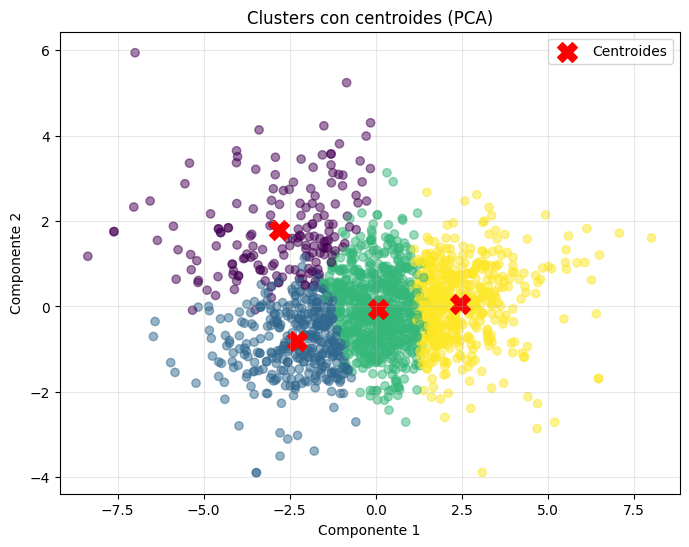

In [ ]:
# Reducir a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

# Centroides en el espacio PCA
centroides_pca = pca.transform(km_std.cluster_centers_)

plt.figure(figsize=(8,6))

# Puntos
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=df_cluster['cluster_final'],
            cmap='viridis', alpha=0.5)

# Centroides
plt.scatter(centroides_pca[:,0], centroides_pca[:,1],
            c='red', s=200, marker='X', label='Centroides')

plt.title("Clusters con centroides (PCA)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()

plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.decomposition import PCA

# PCA a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

# Guardar en el dataframe
df_cluster['pca_x'] = X_pca[:, 0]
df_cluster['pca_y'] = X_pca[:, 1]

In [ ]:
centroides_pca = pca.transform(km_std.cluster_centers_)

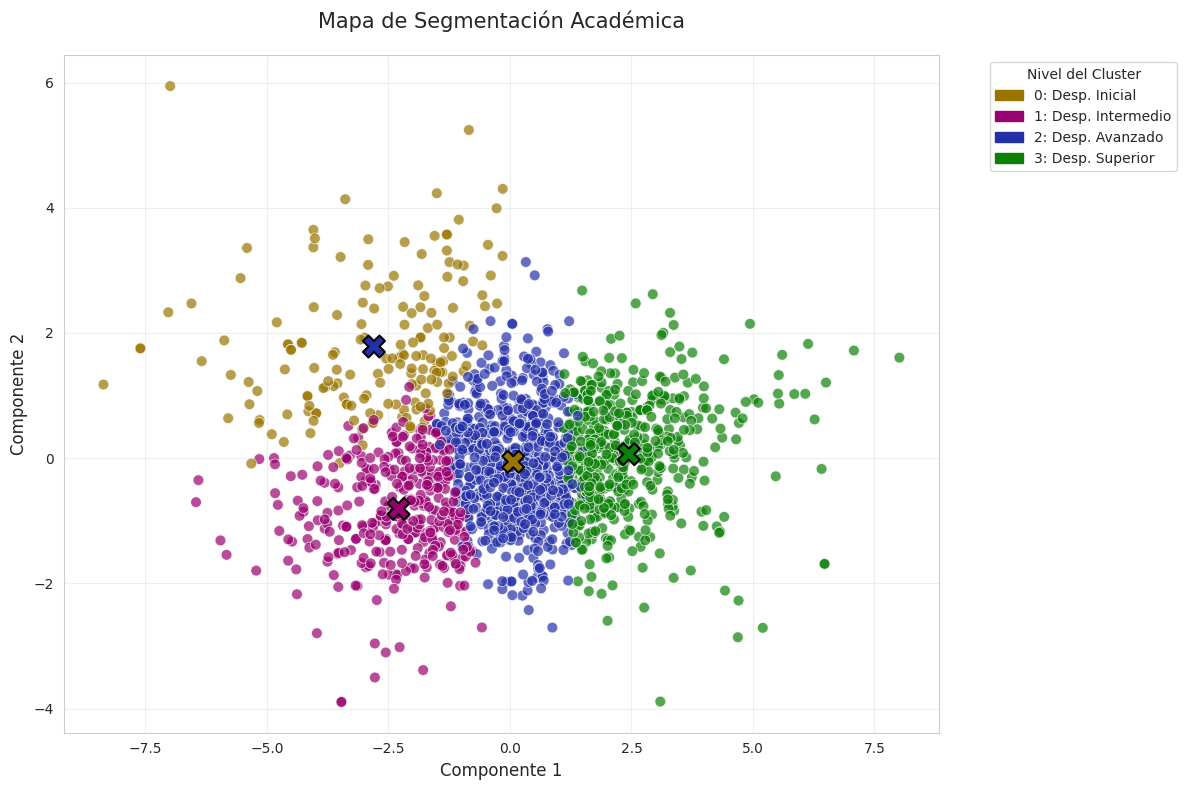

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Colores y nombres (en orden de cluster_final)
mis_colores = ['#997500', '#990070', '#2430a8', '#0b8006']
nombres_clusters = ['0: Desp. Inicial', '1: Desp. Intermedio', '2: Desp. Avanzado', '3: Desp. Superior']

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Scatter de los puntos
sns.scatterplot(
    data=df_cluster,
    x='pca_x', y='pca_y',
    hue='cluster_final',
    palette=mis_colores,
    alpha=0.7,
    s=60,
    edgecolor='w',
    legend=False  # 🔴 importante: desactivamos la automática
)

# 🔴 Añadir centroides (clave)
plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c=mis_colores,
    s=250,
    marker='X',
    edgecolor='black',
    linewidth=1.5,
    label='Centroides'
)

# Títulos
plt.title('Mapa de Segmentación Académica', fontsize=15, pad=20)
plt.xlabel('Componente 1', fontsize=12)
plt.ylabel('Componente 2', fontsize=12)

# 🔹 Leyenda personalizada
legend_handles = [
    mpatches.Patch(color=mis_colores[i], label=nombres_clusters[i])
    for i in range(len(mis_colores))
]

plt.legend(
    handles=legend_handles,
    title='Nivel del Cluster',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
centroides = df_std.groupby('cluster_final').mean()

# Promedio general por cluster (en escala estandarizada)
centroides['promedio_total'] = centroides.mean(axis=1)

print(centroides[['promedio_total']].sort_values('promedio_total'))

               promedio_total
cluster_final                
0                   -0.896754
1                   -0.706653
2                    0.029601
3                    0.753270


In [ ]:
print(cluster_order)
print(new_map)

Index([2, 1, 0, 3], dtype='int32', name='cluster')
{2: 0, 1: 1, 0: 2, 3: 3}


In [ ]:
df_cluster[['cluster', 'cluster_final']].drop_duplicates().sort_values('cluster')

,cluster,cluster_final
1,0,2
11,1,1
17,2,0
8,3,3


In [ ]:
# km_std.cluster_centers_ está en orden original (cluster 0,1,2,3)
centroides_std = km_std.cluster_centers_

# Reordenarlos usando el mismo mapping
centroides_std_reordenados = pd.DataFrame(centroides_std)
centroides_std_reordenados['cluster_original'] = range(n_clusters)

# aplicar el mismo mapeo
centroides_std_reordenados['cluster_final'] = centroides_std_reordenados['cluster_original'].map(new_map)

# ordenar correctamente
centroides_std_reordenados = centroides_std_reordenados.sort_values('cluster_final')

# quitar columnas auxiliares
centroides_std_reordenados = centroides_std_reordenados.drop(columns=['cluster_original', 'cluster_final'])

# convertir a array
centroides_std_reordenados = centroides_std_reordenados.values

In [ ]:
centroides_pca = pca.transform(centroides_std_reordenados)

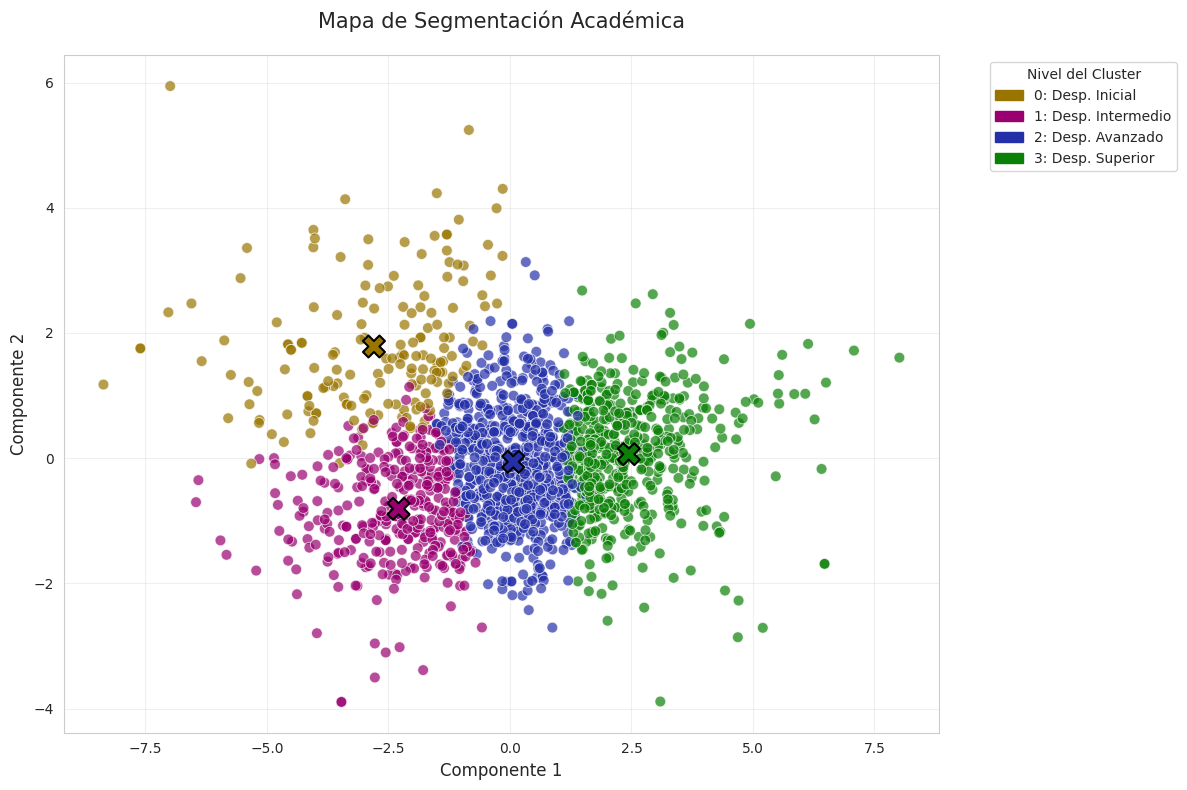

In [ ]:
# Colores y nombres (en orden de cluster_final)
mis_colores = ['#997500', '#990070', '#2430a8', '#0b8006']
nombres_clusters = ['0: Desp. Inicial', '1: Desp. Intermedio', '2: Desp. Avanzado', '3: Desp. Superior']

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Scatter de los puntos
sns.scatterplot(
    data=df_cluster,
    x='pca_x', y='pca_y',
    hue='cluster_final',
    palette=mis_colores,
    alpha=0.7,
    s=60,
    edgecolor='w',
    legend=False  # 🔴 importante: desactivamos la automática
)

# 🔴 Añadir centroides (clave)
plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c=mis_colores,
    s=250,
    marker='X',
    edgecolor='black',
    linewidth=1.5,
    label='Centroides'
)

# Títulos
plt.title('Mapa de Segmentación Académica', fontsize=15, pad=20)
plt.xlabel('Componente 1', fontsize=12)
plt.ylabel('Componente 2', fontsize=12)

# 🔹 Leyenda personalizada
legend_handles = [
    mpatches.Patch(color=mis_colores[i], label=nombres_clusters[i])
    for i in range(len(mis_colores))
]

plt.legend(
    handles=legend_handles,
    title='Nivel del Cluster',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df_cluster.groupby('cluster_final')['total_score'].agg(['mean', 'min', 'max', 'count']).sort_index()

,mean,min,max,count
cluster_final,,,,
0,97.224260,46.4,113.7,169
1,110.108242,83.1,131.6,364
2,122.727557,106.2,143.2,704
3,135.886214,113.0,167.7,515


In [ ]:
centroides = df_std.groupby('cluster_final').mean()

# Promedio general por cluster (en escala estandarizada)
centroides['promedio_total'] = centroides.mean(axis=1)

print(centroides[['promedio_total']].sort_values('promedio_total'))

               promedio_total
cluster_final                
0                   -0.896754
1                   -0.706653
2                    0.029601
3                    0.753270


In [ ]:
# 1. Reducción a 2D para la visualización
pca_2d = PCA(n_components=2)
puntos_2d = pca_2d.fit_transform(X_std) # Usamos los datos estandarizados

df_cluster['pca_x'] = puntos_2d[:, 0]
df_cluster['pca_y'] = puntos_2d[:, 1]

In [ ]:
# 2. Definir tu paleta personalizada (Bajo -> Alto)
mis_colores = ['#997500', '#990070', '#2430a8', '#0b8006']

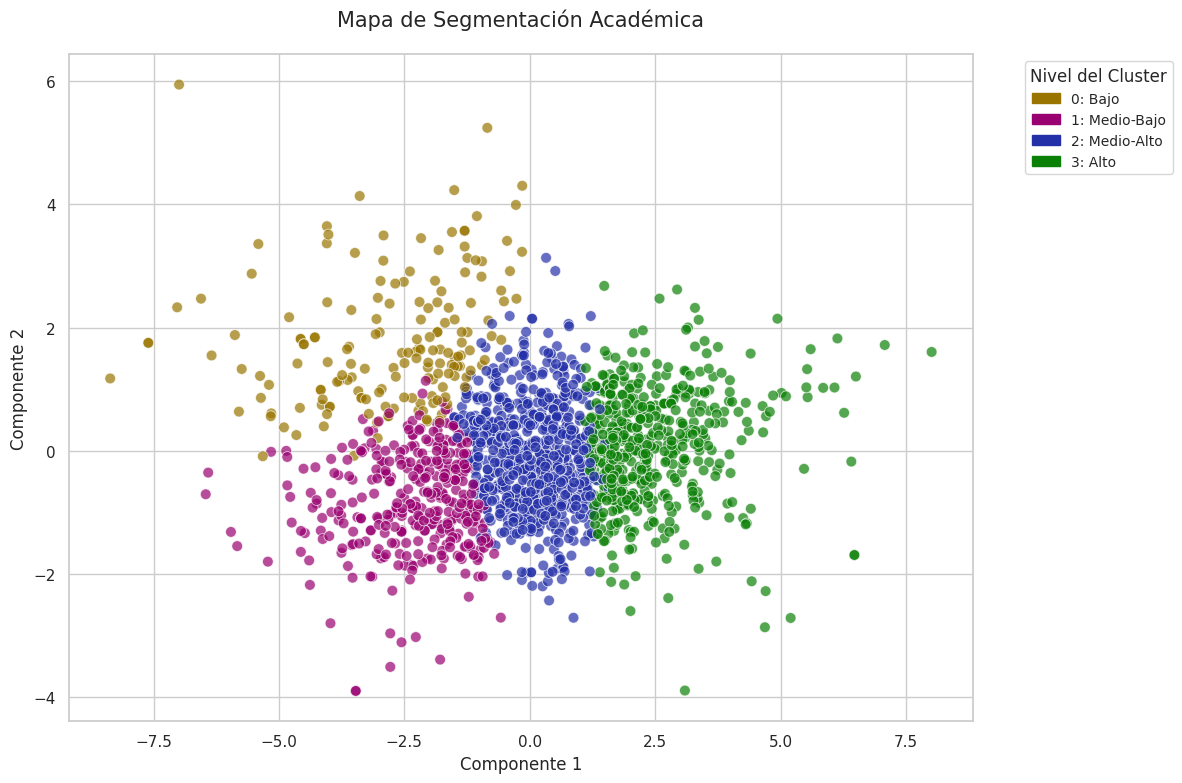

In [ ]:
# 3. Crear la gráfica con Seaborn
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Dibujamos los puntos
scatter = sns.scatterplot(
    data=df_cluster,
    x='pca_x', y='pca_y',
    hue='cluster_final',
    palette=mis_colores,
    alpha=0.7,
    s=60, # Tamaño de los puntos
    edgecolor='w'
)

# Añadir títulos y etiquetas claras
plt.title('Mapa de Segmentación Académica', fontsize=15, pad=20)
plt.xlabel('Componente 1', fontsize=12)
plt.ylabel('Componente 2', fontsize=12)

# 1. Definir los colores y nombres en el orden correcto
mis_colores = ['#997500', '#990070', '#2430a8', '#0b8006']
nombres_clusters = ['0: Bajo', '1: Medio-Bajo', '2: Medio-Alto', '3: Alto']

# 2. Crear los "parches" de color para la leyenda
legend_handles = [mpatches.Patch(color=mis_colores[i], label=nombres_clusters[i])
                  for i in range(len(mis_colores))]

# 3. Dibujar la leyenda usando esos parches
plt.legend(handles=legend_handles, title='Nivel del Cluster',
           bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Definir los nombres pedagógicos
nombres_pedagogicos = {
0: "Cluster0: Académico Inicial",
    1: "Cluster1: Académico Intermedio",
    2: "Cluster2: Académico Avanzado",
    3: "Cluster3: Académico Superior"
}

# Asignar los nombres al DataFrame
df_cluster['nombre_cluster'] = df_cluster['cluster_final'].map(nombres_pedagogicos)

In [ ]:
df_model = df_model.loc[df_cluster.index].copy()
df_model['cluster'] = df_cluster['cluster_final']

In [ ]:
print(df_model.columns.tolist())

['periodo_pro', 'estu_consecutivo_pro', 'estu_tipodocumento_pro', 'estu_pais_reside_pro', 'estu_cod_reside_depto_pro', 'estu_depto_reside_pro', 'estu_cod_reside_mcpio_pro', 'estu_mcpio_reside_pro', 'estu_coddane_cole_termino', 'estu_cod_cole_mcpio_termino', 'estu_cod_depto_presentacion_pro', 'inst_cod_institucion', 'inst_nombre_institucion', 'inst_caracter_academico', 'estu_nucleo_pregrado', 'estu_inst_departamento', 'estu_inst_codmunicipio', 'estu_inst_municipio', 'estu_prgm_academico', 'estu_prgm_departamento', 'estu_prgm_codmunicipio', 'estu_prgm_municipio', 'estu_nivel_prgm_academico', 'estu_metodo_prgm', 'estu_valormatriculauniversidad', 'estu_depto_presentacion_pro', 'estu_cod_mcpio_presentacion_pro', 'estu_mcpio_presentacion_pro', 'estu_pagomatriculabeca', 'estu_pagomatriculacredito', 'estu_horassemanatrabaja', 'estu_snies_prgmacademico', 'estu_privado_libertad_pro', 'estu_nacionalidad_pro', 'estu_estudiante_pro', 'estu_genero_pro', 'estu_cole_termino', 'estu_pagomatriculapadres

In [ ]:
for col in df_model.columns:
    print(col)

periodo_pro
estu_consecutivo_pro
estu_tipodocumento_pro
estu_pais_reside_pro
estu_cod_reside_depto_pro
estu_depto_reside_pro
estu_cod_reside_mcpio_pro
estu_mcpio_reside_pro
estu_coddane_cole_termino
estu_cod_cole_mcpio_termino
estu_cod_depto_presentacion_pro
inst_cod_institucion
inst_nombre_institucion
inst_caracter_academico
estu_nucleo_pregrado
estu_inst_departamento
estu_inst_codmunicipio
estu_inst_municipio
estu_prgm_academico
estu_prgm_departamento
estu_prgm_codmunicipio
estu_prgm_municipio
estu_nivel_prgm_academico
estu_metodo_prgm
estu_valormatriculauniversidad
estu_depto_presentacion_pro
estu_cod_mcpio_presentacion_pro
estu_mcpio_presentacion_pro
estu_pagomatriculabeca
estu_pagomatriculacredito
estu_horassemanatrabaja
estu_snies_prgmacademico
estu_privado_libertad_pro
estu_nacionalidad_pro
estu_estudiante_pro
estu_genero_pro
estu_cole_termino
estu_pagomatriculapadres
estu_estadoinvestigacion_pro
estu_fechanacimiento_pro
estu_pagomatriculapropio
estu_tipodocumentosb11
fami_educa

In [ ]:
df_model.select_dtypes(include='number').columns

Index(['periodo_pro', 'estu_cod_reside_depto_pro', 'estu_cod_reside_mcpio_pro',
       'estu_coddane_cole_termino', 'estu_cod_cole_mcpio_termino',
       'estu_cod_depto_presentacion_pro', 'inst_cod_institucion',
       'estu_inst_codmunicipio', 'estu_prgm_codmunicipio',
       'estu_cod_mcpio_presentacion_pro', 'estu_snies_prgmacademico',
       'mod_razona_cuantitat_punt', 'mod_comuni_escrita_punt',
       'mod_comuni_escrita_desem', 'mod_lectura_critica_punt',
       'mod_ingles_punt', 'mod_competen_ciudada_punt', 'result_puntaje',
       'periodo_sb11', 'periodo_sbpro', 'periodo_sb11',
       'cole_cod_dane_establecimiento', 'cole_cod_dane_sede',
       'cole_cod_depto_ubicacion', 'cole_cod_mcpio_ubicacion',
       'cole_codigo_icfes', 'estu_cod_depto_presentacion_sb11',
       'estu_cod_mcpio_presentacion_sb11', 'estu_cod_reside_depto_sb11',
       'estu_cod_reside_mcpio_sb11', 'punt_ingles', 'punt_matematicas',
       'punt_sociales_ciudadanas', 'punt_c_naturales', 'punt_lectura_

In [ ]:
df_model.select_dtypes(include=['object', 'category']).columns

Index(['estu_consecutivo_pro', 'estu_tipodocumento_pro',
       'estu_pais_reside_pro', 'estu_depto_reside_pro',
       'estu_mcpio_reside_pro', 'inst_nombre_institucion',
       'inst_caracter_academico', 'estu_nucleo_pregrado',
       'estu_inst_departamento', 'estu_inst_municipio', 'estu_prgm_academico',
       'estu_prgm_departamento', 'estu_prgm_municipio',
       'estu_nivel_prgm_academico', 'estu_metodo_prgm',
       'estu_valormatriculauniversidad', 'estu_depto_presentacion_pro',
       'estu_mcpio_presentacion_pro', 'estu_pagomatriculabeca',
       'estu_pagomatriculacredito', 'estu_horassemanatrabaja',
       'estu_privado_libertad_pro', 'estu_nacionalidad_pro',
       'estu_estudiante_pro', 'estu_genero_pro', 'estu_cole_termino',
       'estu_pagomatriculapadres', 'estu_estadoinvestigacion_pro',
       'estu_fechanacimiento_pro', 'estu_pagomatriculapropio',
       'estu_tipodocumentosb11', 'fami_educacionpadre_pro',
       'fami_tieneautomovil_pro', 'fami_tienelavadora_pro',

In [ ]:
# Lista original
vars_cat = df_model.columns.tolist()

# Palabras clave de variables que NO queremos
excluir_keywords = [
    'consecutivo', 'codigo', 'cod_', 'dane', 'snies',
    'nombre', 'id'
]

# Filtrar variables
vars_categoricas_limpias = [
    var for var in vars_cat
    if not any(keyword in var.lower() for keyword in excluir_keywords)
]

# Quitar cluster si ya está incluido
vars_categoricas_limpias = [
    var for var in vars_categoricas_limpias
    if var != 'cluster'
]

print("Número de variables categóricas limpias:", len(vars_categoricas_limpias))
vars_categoricas_limpias[:20]

Número de variables categóricas limpias: 80


['periodo_pro',
 'estu_tipodocumento_pro',
 'inst_caracter_academico',
 'estu_nucleo_pregrado',
 'estu_inst_departamento',
 'estu_inst_codmunicipio',
 'estu_inst_municipio',
 'estu_prgm_academico',
 'estu_prgm_departamento',
 'estu_prgm_codmunicipio',
 'estu_prgm_municipio',
 'estu_nivel_prgm_academico',
 'estu_metodo_prgm',
 'estu_depto_presentacion_pro',
 'estu_mcpio_presentacion_pro',
 'estu_pagomatriculabeca',
 'estu_pagomatriculacredito',
 'estu_horassemanatrabaja',
 'estu_privado_libertad_pro',
 'estu_estudiante_pro']

In [ ]:
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

In [ ]:
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

In [ ]:
vars_11 = [
    "punt_lectura_critica",
    "punt_matematicas",
    "punt_sociales_ciudadanas",
    "punt_c_naturales",
    "punt_ingles"
]

vars_pro = [
    "mod_lectura_critica_punt",
    "mod_comuni_escrita_punt",
    "mod_razona_cuantitat_punt",
    "mod_competen_ciudada_punt",
    "mod_ingles_punt"
]

vars_cluster = vars_pro + vars_11

In [ ]:
excluir_keywords = [
    'consecutivo', 'codigo', 'cod_', 'dane', 'snies',
    'nombre', 'id'
]

In [ ]:
vars_categoricas_final = []

for var in df_model.columns:

    # excluir cluster
    if var == 'cluster':
        continue

    # excluir variables del clustering
    if var in vars_cluster:
        continue

    # excluir IDs
    if any(keyword in var.lower() for keyword in excluir_keywords):
        continue

    # solo categóricas reales
    if df_model[var].dtype != 'object':
        continue

    # evitar alta cardinalidad extrema
    if df_model[var].nunique() > 50:
        continue

    vars_categoricas_final.append(var)

print("Variables categóricas finales:", len(vars_categoricas_final))
vars_categoricas_final[:20]

Variables categóricas finales: 56


['estu_tipodocumento_pro',
 'inst_caracter_academico',
 'estu_nucleo_pregrado',
 'estu_inst_departamento',
 'estu_inst_municipio',
 'estu_prgm_academico',
 'estu_prgm_departamento',
 'estu_prgm_municipio',
 'estu_nivel_prgm_academico',
 'estu_metodo_prgm',
 'estu_depto_presentacion_pro',
 'estu_mcpio_presentacion_pro',
 'estu_pagomatriculabeca',
 'estu_pagomatriculacredito',
 'estu_horassemanatrabaja',
 'estu_privado_libertad_pro',
 'estu_estudiante_pro',
 'estu_genero_pro',
 'estu_pagomatriculapadres',
 'estu_estadoinvestigacion_pro']

In [ ]:
cardinalidad = []

for var in vars_categoricas_final:
    n_cat = df_model[var].nunique()
    cardinalidad.append((var, int(n_cat)))

df_card = pd.DataFrame(cardinalidad, columns=['variable', 'n_categorias'])
df_card = df_card.sort_values(by='n_categorias', ascending=False)

df_card.head(15)

,variable,n_categorias
41,estu_depto_presentacion_sb11,28
36,cole_depto_ubicacion,28
50,fami_personashogar,15
11,estu_mcpio_presentacion_pro,14
28,fami_educacionmadre_pro,12
22,fami_educacionpadre_pro,12
48,fami_educacionpadre_sb11,12
47,fami_educacionmadre_sb11,11
46,fami_cuartoshogar,8
25,fami_estratovivienda_pro,7


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)

    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()

    r, k = tabla.shape

    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

In [ ]:
resultados = []

for var in vars_categoricas_final:

    try:
        df_temp = df_model[['cluster', var]].dropna()

        # evitar variables sin variabilidad
        if df_temp[var].nunique() > 1:

            v = cramers_v(df_temp['cluster'], df_temp[var])

            resultados.append({
                'variable': var,
                'cramers_v': v,
                'n_categorias': df_temp[var].nunique(),
                'n_obs': len(df_temp)
            })

    except Exception as e:
        print(f"Error con {var}: {e}")

In [ ]:
df_cramers = pd.DataFrame(resultados)

df_cramers = df_cramers.sort_values(
    by='cramers_v',
    ascending=False
).reset_index(drop=True)

df_cramers.head(30)

,variable,cramers_v,n_categorias,n_obs
0,desemp_ingles,0.375036,5,1752
1,mod_ingles_desem,0.333206,5,1752
2,estu_inst_departamento,0.268279,2,1752
3,estu_prgm_departamento,0.268279,2,1752
4,estu_nucleo_pregrado,0.258063,3,1752
5,estu_prgm_municipio,0.237883,3,1752
6,estu_inst_municipio,0.237883,3,1752
7,cole_depto_ubicacion,0.218101,28,1752
8,inst_origen,0.217944,3,1752
9,estu_depto_presentacion_sb11,0.217507,28,1752


In [ ]:
vars_final_interpretacion = [
    'estu_nucleo_pregrado',
    'estu_prgm_academico',
    'inst_origen',
    'fami_tienecomputador_sb11',
    'cole_depto_ubicacion',
    'fami_tieneautomovil_sb11',
    'fami_estratovivienda_sb11',
    'estu_genero_sb11',
    'cole_naturaleza',
    'estu_depto_presentacion_sb11',
    'fami_educacionpadre_sb11',
    'fami_educacionmadre_sb11'
]

In [ ]:
resultados = []

for var in vars_final_interpretacion:

    df_temp = df_model[['cluster', var]].dropna()

    if df_temp[var].nunique() > 1:
        v = cramers_v(df_temp['cluster'], df_temp[var])

        resultados.append({
            'variable': var,
            'cramers_v': v
        })

df_final = pd.DataFrame(resultados).sort_values(by='cramers_v', ascending=False)
df_final

,variable,cramers_v
0,estu_nucleo_pregrado,0.258063
4,cole_depto_ubicacion,0.218101
2,inst_origen,0.217944
9,estu_depto_presentacion_sb11,0.217507
1,estu_prgm_academico,0.215512
3,fami_tienecomputador_sb11,0.209063
8,cole_naturaleza,0.196890
5,fami_tieneautomovil_sb11,0.171901
6,fami_estratovivienda_sb11,0.159320
7,estu_genero_sb11,0.144567


In [ ]:
# Tabla de conteo
tabla = pd.crosstab(df_model['cluster'], df_model['estu_nucleo_pregrado'])

# Convertir a proporciones por cluster (fila)
tabla_prop = tabla.div(tabla.sum(axis=1), axis=0)

# Redondear para mejor lectura
tabla_prop = tabla_prop.round(3)

tabla_prop

estu_nucleo_pregrado,ADMINISTRACIÓN,CONTADURÍA PUBLICA,ECONOMÍA
cluster,,,
0,0.834,0.041,0.124
1,0.662,0.223,0.115
2,0.645,0.121,0.234
3,0.394,0.113,0.493


In [ ]:
tabla_prop = tabla_prop[tabla_prop.sum().sort_values(ascending=False).index]
tabla_prop

estu_nucleo_pregrado,ADMINISTRACIÓN,ECONOMÍA,CONTADURÍA PUBLICA
cluster,,,
0,0.834,0.124,0.041
1,0.662,0.115,0.223
2,0.645,0.234,0.121
3,0.394,0.493,0.113


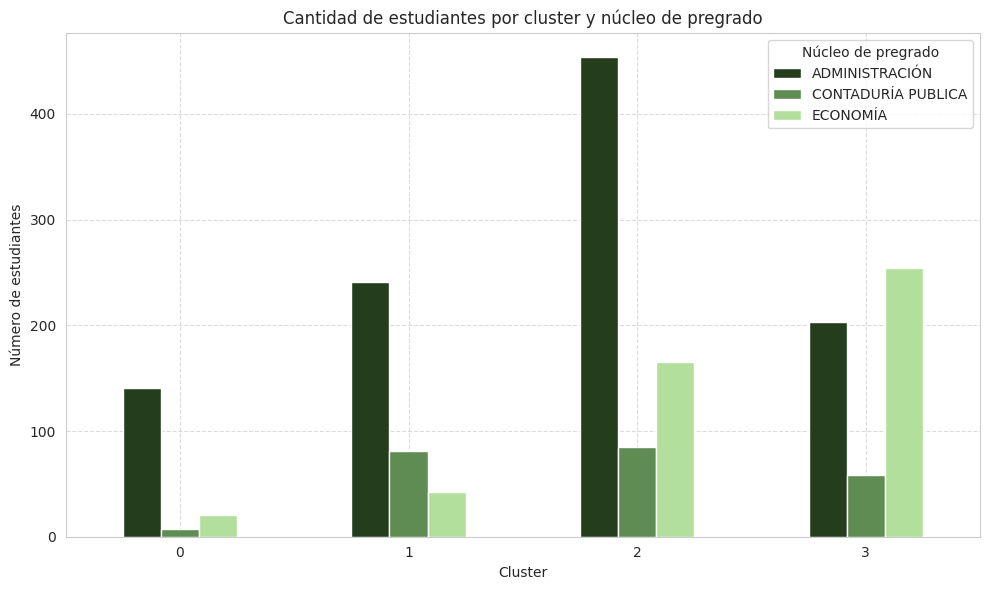

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Tabla de conteo (frecuencias absolutas)
tabla_counts = pd.crosstab(df_model['cluster'], df_model['estu_nucleo_pregrado'])

# Paleta de colores personalizada
colores = ['#233d1d', '#5f8c52', '#b2df9c']

# Gráfica de barras con la paleta de colores
ax = tabla_counts.plot(kind='bar', figsize=(10,6), color=colores)

# Activar líneas de fondo (grid)
ax.grid(True, linestyle='--', alpha=0.7)

# Personalizar el gráfico
plt.title('Cantidad de estudiantes por cluster y núcleo de pregrado')
plt.xlabel('Cluster')
plt.ylabel('Número de estudiantes')

plt.xticks(rotation=0)
plt.legend(title='Núcleo de pregrado')

plt.tight_layout()
plt.show()

In [ ]:
# Tabla de conteo
tabla = pd.crosstab(df_model['cluster'], df_model['inst_origen'])

# Proporciones por cluster
tabla_prop = tabla.div(tabla.sum(axis=1), axis=0)

# Redondear
tabla_prop = tabla_prop.round(3)

tabla_prop

inst_origen,NO OFICIAL - CORPORACIÓN,NO OFICIAL - FUNDACIÓN,OFICIAL NACIONAL
cluster,,,
0,0.012,0.917,0.071
1,0.003,0.750,0.247
2,0.000,0.791,0.209
3,0.000,0.522,0.478


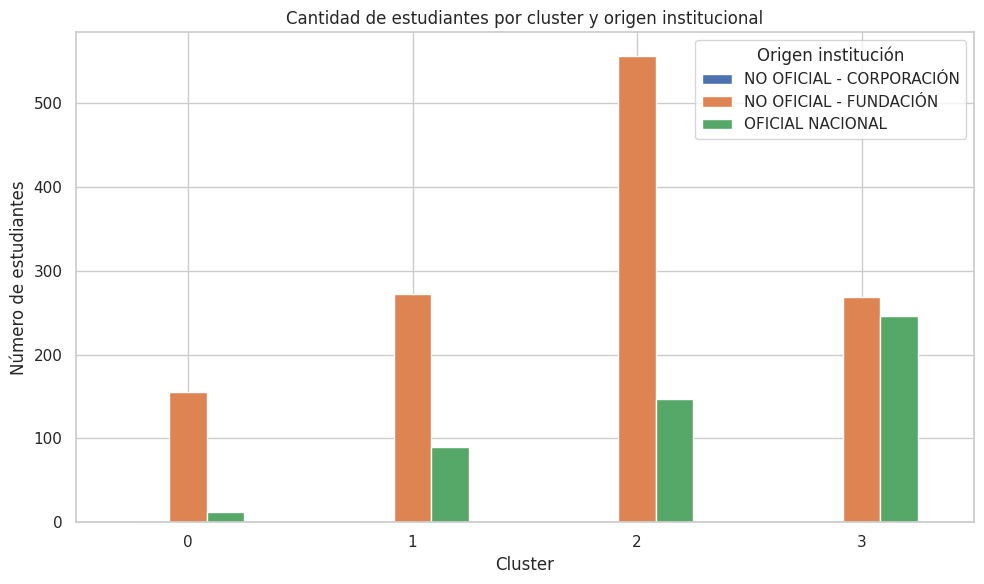

In [ ]:
tabla.plot(kind='bar', figsize=(10,6))

plt.title('Cantidad de estudiantes por cluster y origen institucional')
plt.xlabel('Cluster')
plt.ylabel('Número de estudiantes')

plt.xticks(rotation=0)
plt.legend(title='Origen institución')

plt.tight_layout()
plt.show()

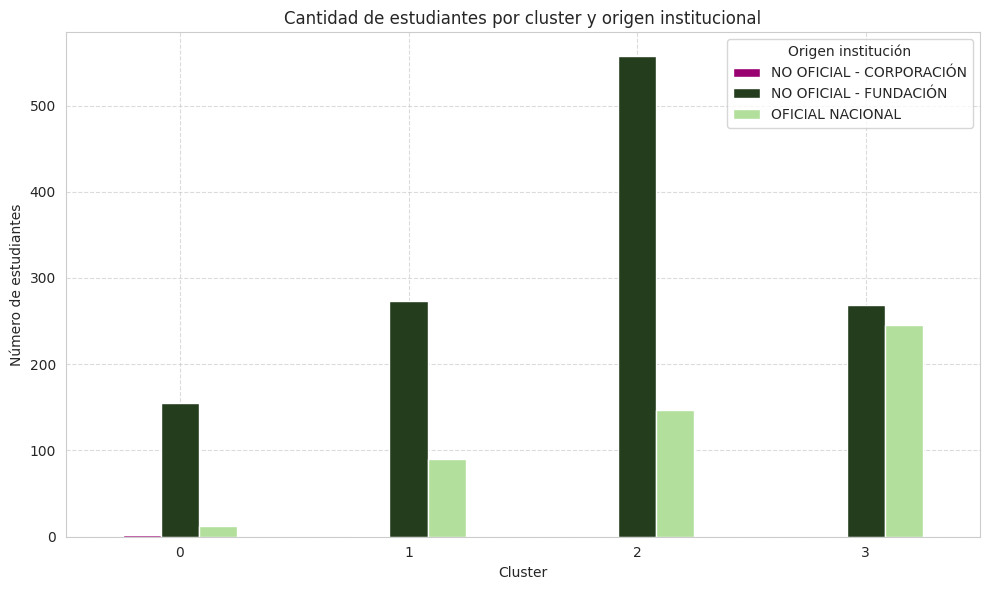

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Paleta de colores personalizada
colores = ['#990070', '#233d1d', '#b2df9c', '#0b8006']

# Gráfica de barras con la paleta de colores
ax = tabla.plot(kind='bar', figsize=(10,6), color=colores)

# Activar líneas de fondo (grid)
ax.grid(True, linestyle='--', alpha=0.7)

plt.title('Cantidad de estudiantes por cluster y origen institucional')
plt.xlabel('Cluster')
plt.ylabel('Número de estudiantes')

plt.xticks(rotation=0)
plt.legend(title='Origen institución')

plt.tight_layout()
plt.show()

In [ ]:
# Tabla de conteo
tabla = pd.crosstab(df_model['cluster'], df_model['fami_tienecomputador_sb11'])

# Proporciones por cluster
tabla_prop = tabla.div(tabla.sum(axis=1), axis=0)

# Redondear
tabla_prop = tabla_prop.round(3)

tabla_prop

fami_tienecomputador_sb11,No,Si
cluster,,
0,0.006,0.994
1,0.160,0.840
2,0.050,0.950
3,0.033,0.967


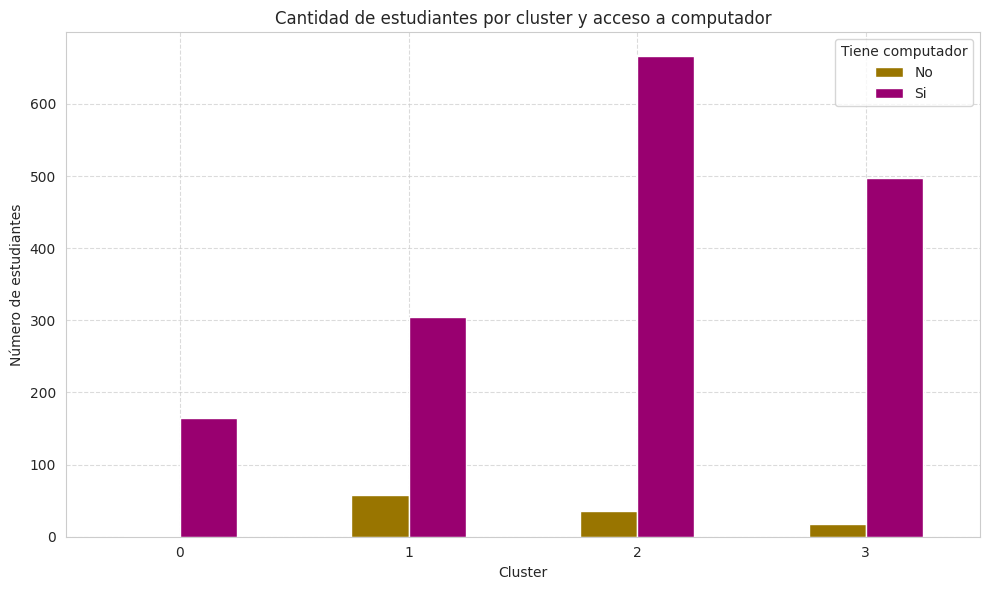

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Paleta de colores personalizada
colores = ['#997500', '#990070', '#2430a8', '#0b8006']

# Gráfica de barras con la paleta de colores
ax = tabla.plot(kind='bar', figsize=(10,6), color=colores)

# Activar líneas de fondo (grid)
ax.grid(True, linestyle='--', alpha=0.7)

plt.title('Cantidad de estudiantes por cluster y acceso a computador')
plt.xlabel('Cluster')
plt.ylabel('Número de estudiantes')

plt.xticks(rotation=0)
plt.legend(title='Tiene computador')

plt.tight_layout()
plt.show()

In [ ]:
# Tabla de conteo
tabla = pd.crosstab(df_model['cluster'], df_model['fami_tienelavadora_sb11'])

# Proporciones por cluster
tabla_prop = tabla.div(tabla.sum(axis=1), axis=0)

# Redondear
tabla_prop = tabla_prop.round(3)

tabla_prop

fami_tienelavadora_sb11,No,Si
cluster,,
0,0.012,0.988
1,0.171,0.829
2,0.061,0.939
3,0.043,0.957


In [ ]:
# Tabla de conteo
tabla = pd.crosstab(df_model['cluster'], df_model['cole_naturaleza'])

# Proporciones por cluster
tabla_prop = tabla.div(tabla.sum(axis=1), axis=0)

# Redondear
tabla_prop = tabla_prop.round(3)

tabla_prop

cole_naturaleza,NO OFICIAL,OFICIAL
cluster,,
0,0.923,0.077
1,0.681,0.319
2,0.837,0.163
3,0.864,0.136


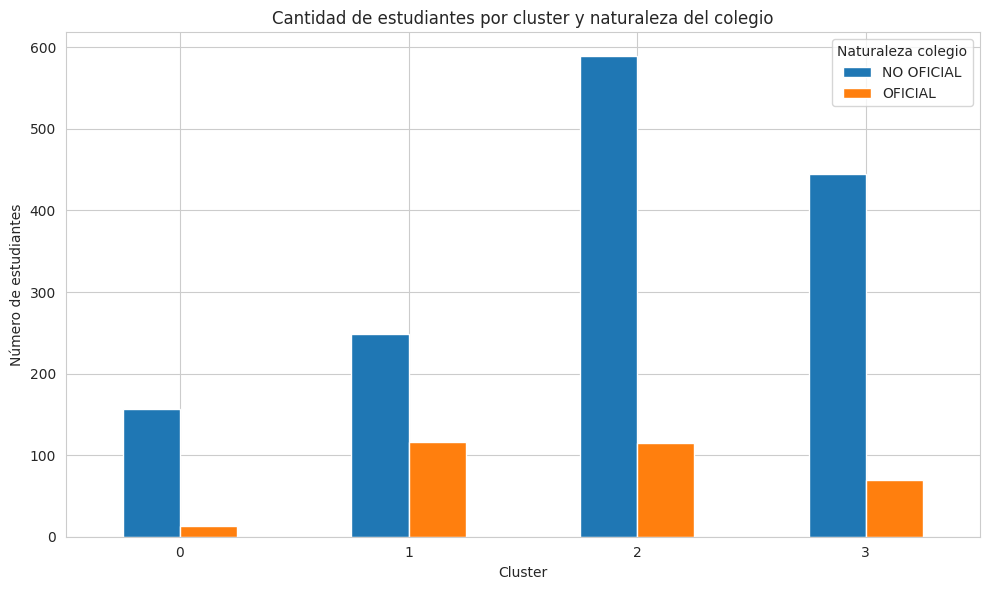

In [ ]:
tabla.plot(kind='bar', figsize=(10,6))

plt.title('Cantidad de estudiantes por cluster y naturaleza del colegio')
plt.xlabel('Cluster')
plt.ylabel('Número de estudiantes')

plt.xticks(rotation=0)
plt.legend(title='Naturaleza colegio')

plt.tight_layout()
plt.show()

In [ ]:
tabla = pd.crosstab(df_model['cluster'], df_model['cole_depto_ubicacion'])

tabla_prop = tabla.div(tabla.sum(axis=1), axis=0).round(3)

tabla_prop

cole_depto_ubicacion,AMAZONAS,ANTIOQUIA,ARAUCA,ATLANTICO,BOGOTA,BOLIVAR,BOYACA,CALDAS,CAQUETA,CASANARE,...,NARIÑO,NORTE SANTANDER,PUTUMAYO,QUINDIO,RISARALDA,SAN ANDRES,SANTANDER,SUCRE,TOLIMA,VALLE
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.000,0.000,0.006,0.006,0.402,0.018,0.018,0.006,0.000,0.000,...,0.012,0.018,0.000,0.000,0.018,0.000,0.012,0.000,0.000,0.355
1,0.005,0.000,0.003,0.003,0.401,0.003,0.036,0.003,0.000,0.014,...,0.055,0.005,0.005,0.005,0.000,0.000,0.016,0.003,0.005,0.310
2,0.000,0.001,0.000,0.007,0.567,0.017,0.020,0.007,0.001,0.004,...,0.013,0.006,0.004,0.001,0.011,0.003,0.011,0.000,0.004,0.173
3,0.000,0.000,0.000,0.004,0.674,0.006,0.029,0.000,0.000,0.006,...,0.002,0.014,0.000,0.002,0.004,0.000,0.010,0.000,0.016,0.097


In [ ]:
top_deptos = tabla.sum().sort_values(ascending=False).head(10).index

tabla_top = tabla[top_deptos]

tabla_top_prop = tabla_top.div(tabla_top.sum(axis=1), axis=0).round(3)

tabla_top_prop

cole_depto_ubicacion,BOGOTA,VALLE,CUNDINAMARCA,BOYACA,NARIÑO,META,SANTANDER,BOLIVAR,HUILA,NORTE SANTANDER
cluster,,,,,,,,,,
0,0.433,0.382,0.057,0.019,0.013,0.025,0.013,0.019,0.019,0.019
1,0.436,0.337,0.087,0.039,0.060,0.006,0.018,0.003,0.009,0.006
2,0.617,0.189,0.104,0.022,0.014,0.009,0.012,0.019,0.009,0.006
3,0.705,0.102,0.100,0.030,0.002,0.018,0.010,0.006,0.012,0.014


In [ ]:
tabla_inv = pd.crosstab(df_model['cole_depto_ubicacion'], df_model['cluster'])

tabla_inv_prop = tabla_inv.div(tabla_inv.sum(axis=1), axis=0).round(3)

tabla_inv_prop.head(10)

cluster,0,1,2,3
cole_depto_ubicacion,,,,
AMAZONAS,0.000,1.000,0.000,0.000
ANTIOQUIA,0.000,0.000,1.000,0.000
ARAUCA,0.500,0.500,0.000,0.000
ATLANTICO,0.111,0.111,0.556,0.222
BOGOTA,0.071,0.152,0.416,0.361
BOLIVAR,0.158,0.053,0.632,0.158
BOYACA,0.067,0.289,0.311,0.333
CALDAS,0.143,0.143,0.714,0.000
CAQUETA,0.000,0.000,1.000,0.000


In [ ]:
brecha = tabla_inv_prop[3] - tabla_inv_prop[0]

brecha.sort_values(ascending=False).head(10)

,0
cole_depto_ubicacion,
TOLIMA,0.615
BOGOTA,0.290
CASANARE,0.273
BOYACA,0.266
CUNDINAMARCA,0.260
QUINDIO,0.250
NORTE SANTANDER,0.250
META,0.239
HUILA,0.166


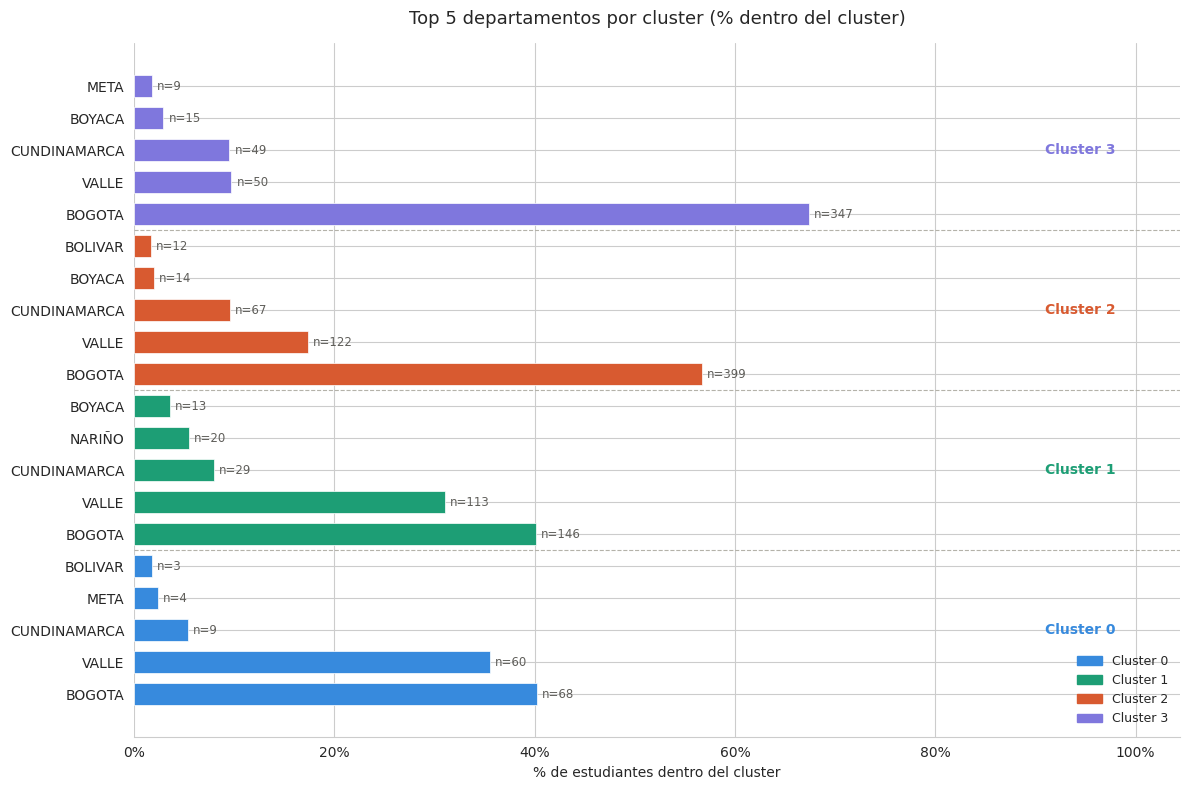

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# 1. Tabla de conteo
tabla = pd.crosstab(df_model['cole_depto_ubicacion'], df_model['cluster'])

# 2. Top 5 por cada cluster (valor real de ESE cluster)
colores = {0: '#378ADD', 1: '#1D9E75', 2: '#D85A30', 3: '#7F77DD'}

filas = []
for cluster_id in sorted(tabla.columns):
    total_cluster = tabla[cluster_id].sum()
    top5 = tabla[cluster_id].nlargest(5)
    for depto, valor in top5.items():
        filas.append({
            'depto': depto,
            'valor': valor,
            'porcentaje': valor / total_cluster * 100,  # % dentro del cluster
            'cluster': int(cluster_id)
        })

df_plot = pd.DataFrame(filas)

# 3. Datos para graficar
deptos = df_plot['depto'].tolist()
porcentajes = df_plot['porcentaje'].values
valores = df_plot['valor'].values
clusters = df_plot['cluster'].tolist()
bar_colors = [colores[c] for c in clusters]
y = np.arange(len(deptos))

# 4. Figura
plt.close('all')
fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(y, porcentajes, color=bar_colors, height=0.7, edgecolor='white', linewidth=0.5)

# 5. Etiqueta n= al final de cada barra
for i, (pct, n) in enumerate(zip(porcentajes, valores)):
    ax.text(pct + 0.5, i, f'n={n:,}',
            va='center', ha='left', fontsize=8.5, color='#5F5E5A')

# 6. Separadores entre clusters
for i in range(1, len(clusters)):
    if clusters[i] != clusters[i - 1]:
        ax.axhline(y=i - 0.5, color='#B4B2A9', linewidth=0.8, linestyle='--')

# 7. Etiqueta de cluster a la derecha
max_pct = porcentajes.max()
cluster_actual = None
for i, c in enumerate(clusters):
    if c != cluster_actual:
        grupo = [j for j, x in enumerate(clusters) if x == c]
        centro = np.mean(grupo)
        ax.text(max_pct * 1.35, centro, f'Cluster {c}',
                va='center', ha='left', fontsize=10,
                fontweight='bold', color=colores[c])
        cluster_actual = c

# 8. Estilo
ax.set_yticks(y)
ax.set_yticklabels(deptos, fontsize=10)
ax.set_xlabel('% de estudiantes dentro del cluster', fontsize=10)
ax.set_title('Top 5 departamentos por cluster (% dentro del cluster)', fontsize=13, pad=14)
ax.set_xlim(0, max_pct * 1.55)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)

# 9. Leyenda
patches = [mpatches.Patch(color=col, label=f'Cluster {c}') for c, col in colores.items()]
ax.legend(handles=patches, frameon=False, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
tabla_inv_prop

cluster,0,1,2,3
cole_depto_ubicacion,,,,
AMAZONAS,0.000,1.000,0.000,0.000
ANTIOQUIA,0.000,0.000,1.000,0.000
ARAUCA,0.500,0.500,0.000,0.000
ATLANTICO,0.111,0.111,0.556,0.222
BOGOTA,0.071,0.152,0.416,0.361
BOLIVAR,0.158,0.053,0.632,0.158
BOYACA,0.067,0.289,0.311,0.333
CALDAS,0.143,0.143,0.714,0.000
CAQUETA,0.000,0.000,1.000,0.000


In [ ]:
tabla_diff = (tabla_prop.loc[3] - tabla_prop.loc[0]).sort_values(ascending=False)

tabla_diff

,0
cole_depto_ubicacion,
BOGOTA,0.272
CUNDINAMARCA,0.042
TOLIMA,0.016
BOYACA,0.011
CASANARE,0.006
QUINDIO,0.002
CAUCA,0.002
CAQUETA,0.000
LA GUAJIRA,0.000


In [ ]:
brecha = tabla_inv_prop[3] - tabla_inv_prop[0]

brecha.sort_values(ascending=False).head(10)

,0
cole_depto_ubicacion,
TOLIMA,0.615
BOGOTA,0.290
CASANARE,0.273
BOYACA,0.266
CUNDINAMARCA,0.260
QUINDIO,0.250
NORTE SANTANDER,0.250
META,0.239
HUILA,0.166


In [ ]:
# Conteo total por programa
conteo = df_model['estu_prgm_academico'].value_counts()

# Top 5 o 6 programas
top_programas = conteo.head(6).index

df_filtrado = df_model[df_model['estu_prgm_academico'].isin(top_programas)]

In [ ]:
tabla = pd.crosstab(df_filtrado['cluster'], df_filtrado['estu_prgm_academico'])

tabla_prop = tabla.div(tabla.sum(axis=1), axis=0).round(3)

tabla_prop

estu_prgm_academico,ADMINISTRACION DE EMPRESAS,ADMINISTRACION DE EMPRESAS.,CONTADURIA PUBLICA,ECONOMIA
cluster,,,,
0,0.822,0.012,0.041,0.124
1,0.659,0.003,0.223,0.115
2,0.645,0.000,0.121,0.234
3,0.394,0.000,0.113,0.493


In [ ]:
tabla = pd.crosstab(df_model['cluster'], df_model['fami_educacionpadre_sb11'])

tabla_prop = tabla.div(tabla.sum(axis=1), axis=0).round(3)

tabla_prop

fami_educacionpadre_sb11,Educación profesional completa,Educación profesional incompleta,Ninguno,No Aplica,No sabe,Postgrado,Primaria completa,Primaria incompleta,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) incompleta,Técnica o tecnológica completa,Técnica o tecnológica incompleta
cluster,,,,,,,,,,,,
0,0.445,0.043,0.006,0.000,0.006,0.220,0.012,0.012,0.110,0.049,0.079,0.018
1,0.289,0.022,0.006,0.003,0.022,0.132,0.033,0.077,0.220,0.077,0.091,0.028
2,0.410,0.043,0.010,0.004,0.034,0.192,0.024,0.023,0.123,0.042,0.076,0.017
3,0.381,0.039,0.016,0.002,0.041,0.216,0.045,0.023,0.109,0.031,0.086,0.012


In [ ]:
tabla_diff = (tabla_prop.loc[3] - tabla_prop.loc[0]).sort_values(ascending=False)

tabla_diff

,0
fami_educacionpadre_sb11,
No sabe,0.035
Primaria completa,0.033
Primaria incompleta,0.011
Ninguno,0.010
Técnica o tecnológica completa,0.007
No Aplica,0.002
Secundaria (Bachillerato) completa,-0.001
Educación profesional incompleta,-0.004
Postgrado,-0.004


In [ ]:
tabla_inv = pd.crosstab(df_model['fami_educacionpadre_sb11'], df_model['cluster'])

tabla_inv_prop = tabla_inv.div(tabla_inv.sum(axis=1), axis=0).round(3)

tabla_inv_prop

cluster,0,1,2,3
fami_educacionpadre_sb11,,,,
Educación profesional completa,0.111,0.159,0.433,0.297
Educación profesional incompleta,0.108,0.123,0.462,0.308
Ninguno,0.056,0.111,0.389,0.444
No Aplica,0.000,0.200,0.600,0.200
No sabe,0.019,0.148,0.444,0.389
Postgrado,0.109,0.146,0.407,0.337
Primaria completa,0.037,0.222,0.315,0.426
Primaria incompleta,0.034,0.483,0.276,0.207
Secundaria (Bachillerato) completa,0.075,0.333,0.358,0.233


In [ ]:
cols_fami = [c for c in df_full.columns if 'fami_' in c or 'estrato' in c]
print(cols_fami)

['fami_educacionpadre_pro', 'fami_tieneautomovil_pro', 'fami_tienelavadora_pro', 'fami_estratovivienda_pro', 'fami_tienecomputador_pro', 'fami_tieneinternet_pro', 'fami_educacionmadre_pro', 'fami_cuartoshogar', 'fami_educacionmadre_sb11', 'fami_educacionpadre_sb11', 'fami_estratovivienda_sb11', 'fami_personashogar', 'fami_tieneautomovil_sb11', 'fami_tienecomputador_sb11', 'fami_tieneinternet_sb11', 'fami_tienelavadora_sb11']


In [ ]:
# 1. Ver cómo está el cluster en df_full (o si solo está en df_cluster)
print("cluster en df_full:", "cluster" in df_full.columns)

# 2. Ver categorías únicas de cada variable
for col in ['fami_estratovivienda_sb11', 'fami_tieneautomovil_sb11', 'fami_tienecomputador_sb11']:
    print(f"\n{col}:", df_full[col].unique())

cluster en df_full: False

fami_estratovivienda_sb11: ['Estrato 4' 'Estrato 5' 'Estrato 6' 'Estrato 3' 'Estrato 2' 'Estrato 1'
 nan 'Sin Estrato']

fami_tieneautomovil_sb11: ['Si' 'No' nan]

fami_tienecomputador_sb11: ['Si' 'No' nan]


In [ ]:
df_cluster['score_11'] = df_cluster[vars_11].mean(axis=1)

In [ ]:
df_cluster['nivel_11'] = pd.qcut(
    df_cluster['score_11'],
    q=4,
    labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto']
)

In [ ]:
tabla_cruce = pd.crosstab(
    df_cluster['nivel_11'],
    df_cluster['cluster_final'],
    normalize='index'  # 🔴 esto da proporciones por fila
)

print(tabla_cruce.round(3))

cluster_final      0      1      2      3
nivel_11                                 
Bajo           0.153  0.783  0.064  0.000
Medio-Bajo     0.143  0.048  0.803  0.007
Medio-Alto     0.053  0.000  0.648  0.299
Alto           0.037  0.000  0.085  0.878


In [ ]:
orden_filas = ['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto']
orden_cols = [0, 1, 2, 3]

tabla_cruce = tabla_cruce.reindex(index=orden_filas, columns=orden_cols)

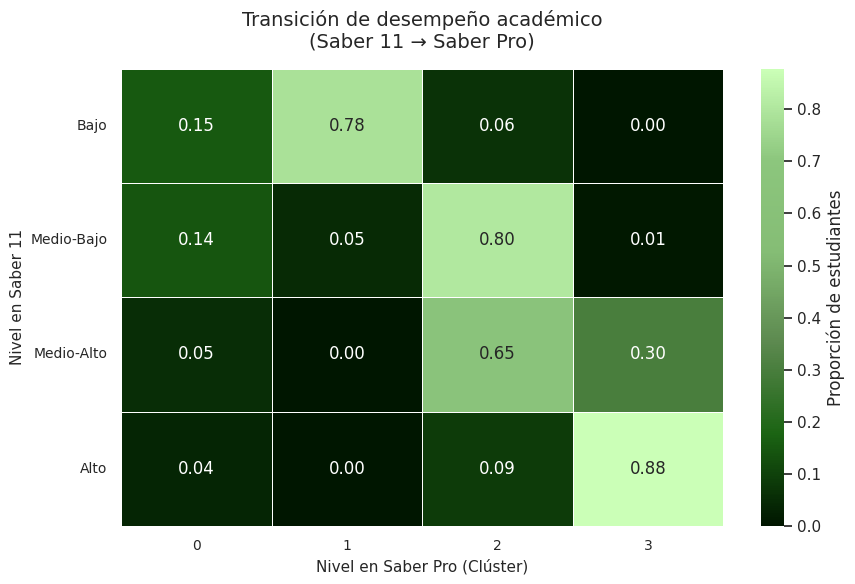

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 🔹 Crear paleta personalizada
colores = ["#001600", "#1b6413", "#5c894f", "#85bd75", "#8cc67d", "#cbffb7"]
cmap_custom = LinearSegmentedColormap.from_list("mi_paleta", colores)

# 🔹 Estilo general
sns.set_theme(style="white")

plt.figure(figsize=(9, 6))

# 🔹 Heatmap
ax = sns.heatmap(
    tabla_cruce,
    annot=True,
    fmt=".2f",
    cmap=cmap_custom,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        "label": "Proporción de estudiantes"
    }
)

# 🔹 Títulos y etiquetas
plt.title("Transición de desempeño académico\n(Saber 11 → Saber Pro)",
          fontsize=14, pad=15)

plt.xlabel("Nivel en Saber Pro (Clúster)", fontsize=11)
plt.ylabel("Nivel en Saber 11", fontsize=11)

# 🔹 Mejorar ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)

# 🔹 Ajuste final
plt.tight_layout()
plt.show()

In [ ]:
map_cols = {
    0: "Inicial",
    1: "Intermedio",
    2: "Avanzado",
    3: "Superior"
}

tabla_cruce_renombrada = tabla_cruce.rename(columns=map_cols)

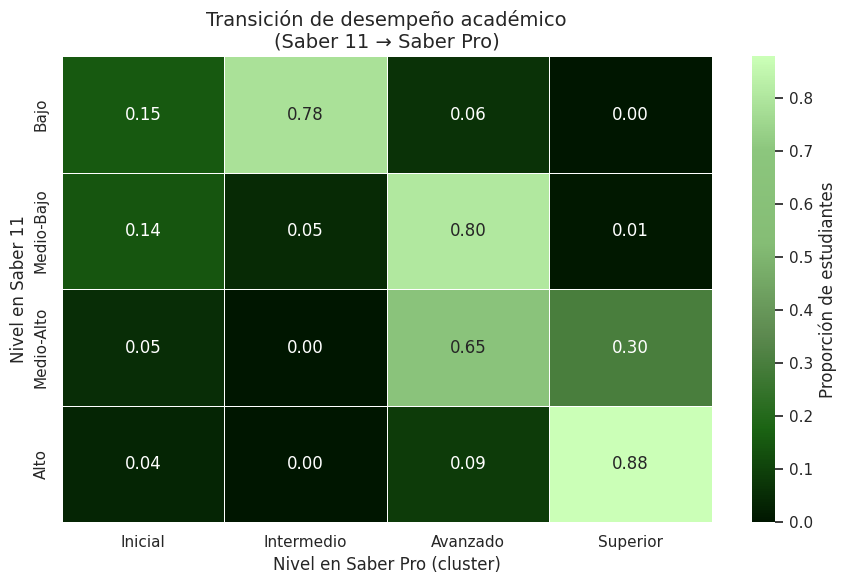

In [ ]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    tabla_cruce_renombrada,
    annot=True,
    fmt=".2f",
    cmap=cmap_custom,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"label": "Proporción de estudiantes"}
)

plt.title("Transición de desempeño académico\n(Saber 11 → Saber Pro)", fontsize=14)
plt.xlabel("Nivel en Saber Pro (cluster)")
plt.ylabel("Nivel en Saber 11")

plt.tight_layout()
plt.show()